In [167]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [168]:
df=pd.read_csv('insurance.csv')

In [169]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [170]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [171]:
df.sample(5)

,age,sex,bmi,children,smoker,region,charges
26,63,female,23.085,0,no,northeast,14451.83515
451,30,male,24.130,1,no,northwest,4032.24070
39,60,male,39.900,0,yes,southwest,48173.36100
343,63,male,36.765,0,no,northeast,13981.85035
860,37,female,47.600,2,yes,southwest,46113.51100


In [172]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [173]:
df.shape

(1338, 7)

In [174]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [175]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [176]:
df.duplicated().sum()

np.int64(1)

In [177]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [178]:
df.drop_duplicates(inplace=True)

In [179]:
df.shape

(1337, 7)

In [180]:
print(df['sex'].value_counts())    
print(40*'=')

print(df['smoker'].value_counts())
print(40*'=')


print(df['region'].value_counts())  
print(40*'=')
    

print(df['children'].value_counts())
print(40*'=')


sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64
children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


Smoking has the strongest impact on medical insurance charges.
Medical charges generally increase with age.
Higher BMI is associated with higher insurance charges.
Gender has little effect on insurance charges.
The number of children has a relatively small effect on insurance charges.
1Region does not significantly affect medical charges.

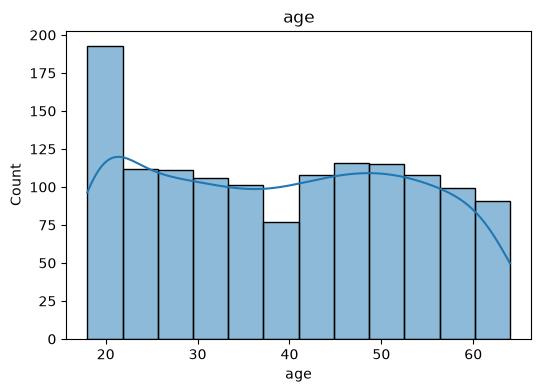

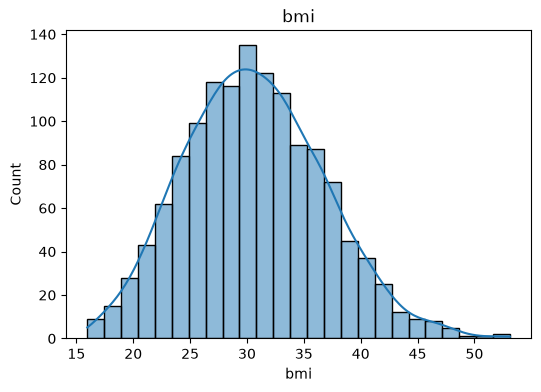

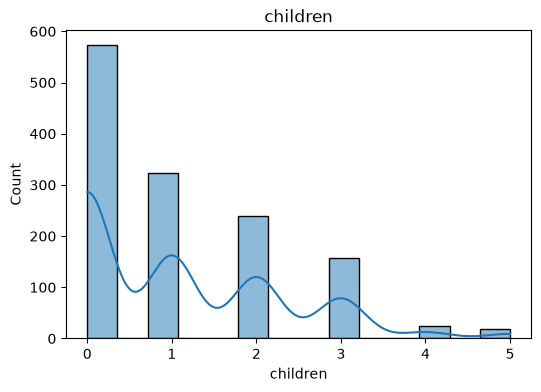

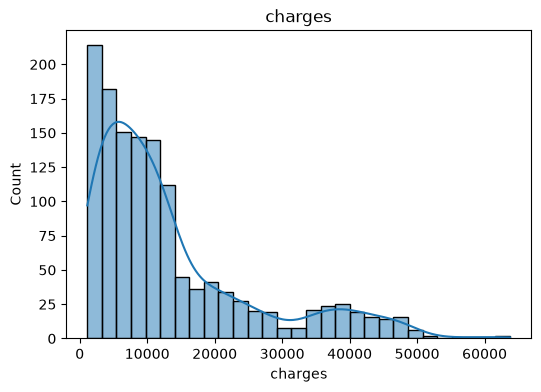

In [181]:
num_cols = ['age', 'bmi', 'children', 'charges']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

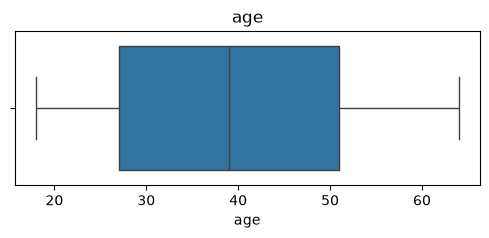

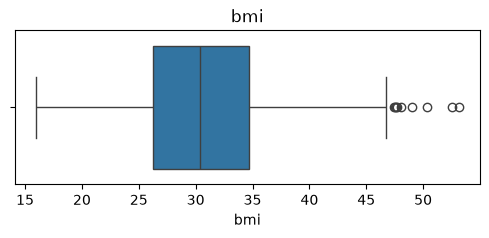

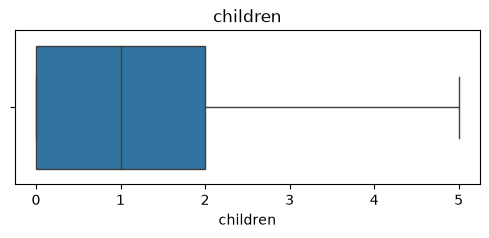

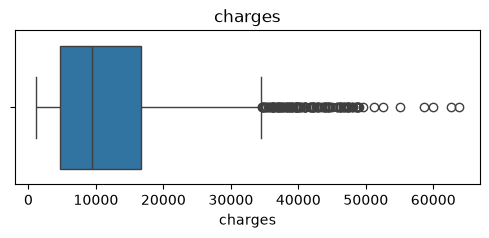

In [182]:
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

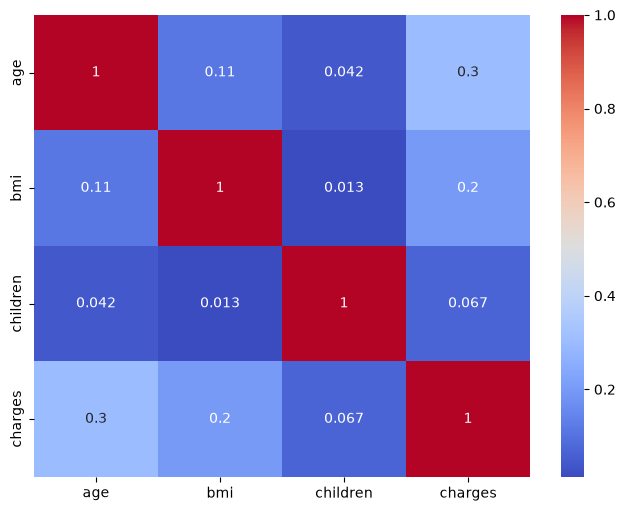

In [183]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

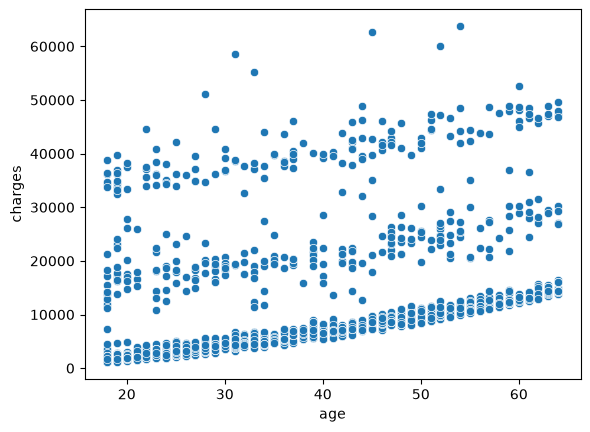

In [184]:
sns.scatterplot(data=df, x='age', y='charges')
plt.show()

In [185]:
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

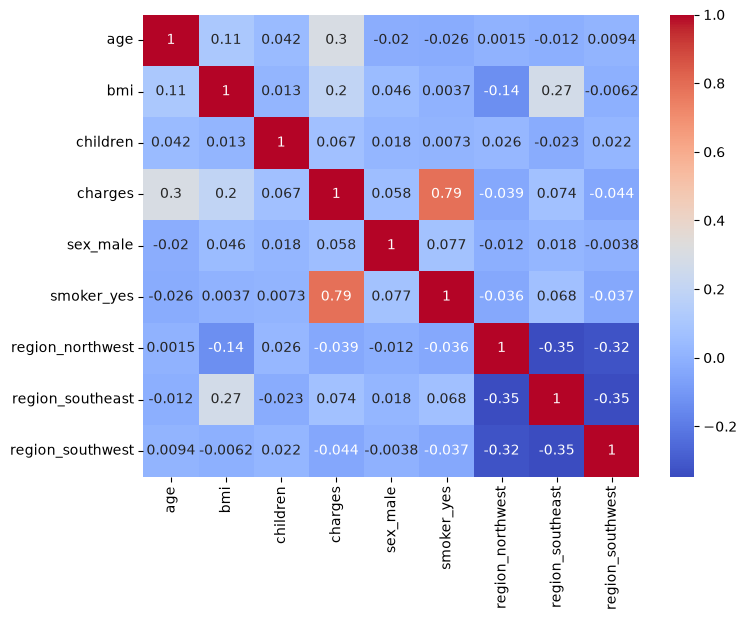

In [186]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [187]:
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [188]:
X=df.drop('charges', axis=1)
y=df['charges']

### *1- Linear Regression*

In [189]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr_model = LinearRegression()

In [190]:
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

In [191]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("MSE :", mean_squared_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 :", r2_score(y_test, lr_pred))

MAE : 4177.045561036319
MSE : 35478020.67523559
RMSE: 5956.342894363587
R2 : 0.8069287081198012


In [192]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})

print(coefficients.sort_values(by='Coefficient', ascending=False))

            Feature   Coefficient
4        smoker_yes  23077.764593
2          children    533.009989
1               bmi    318.701441
0               age    248.210720
3          sex_male   -101.542054
5  region_northwest   -391.761455
7  region_southwest   -659.139752
6  region_southeast   -838.919616


### *2-Decision Tree Regressor*

In [193]:
from sklearn.tree import DecisionTreeRegressor

dt_model= DecisionTreeRegressor(max_depth=5,random_state=42)
dt_model.fit(X_train, y_train)
dt_pred=dt_model.predict(X_test)


print("Decision Tree")
print("MAE :", mean_absolute_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 :", r2_score(y_test, dt_pred))

Decision Tree
MAE : 2656.8390786583914
RMSE: 4411.537636335603
R2 : 0.8940896757972968


### *3-RandomForestRegressor*

In [194]:
from sklearn.ensemble import RandomForestRegressor

rf_model= RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)  

rf_pred=rf_model.predict(X_test)


print("Random Forest")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 :", r2_score(y_test, rf_pred))


Random Forest
MAE : 2418.0250058222487
RMSE: 4248.61532692342
R2 : 0.9017679645547299


### *4- XGBRegressor*

In [195]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train) 

xgb_pred=xgb_model.predict(X_test)

print("XGBoost")
print("MAE :", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R2 :", r2_score(y_test, xgb_pred))


XGBoost
MAE : 2527.5760823269
RMSE: 4440.256967181291
R2 : 0.8927062242136821


### *Compare Models*

In [196]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ]
})

comparison = comparison.sort_values("R2 Score", ascending=False)

print(comparison)

               Model  R2 Score         RMSE
2      Random Forest  0.901768  4248.615327
1      Decision Tree  0.894090  4411.537636
3            XGBoost  0.892706  4440.256967
0  Linear Regression  0.806929  5956.342894


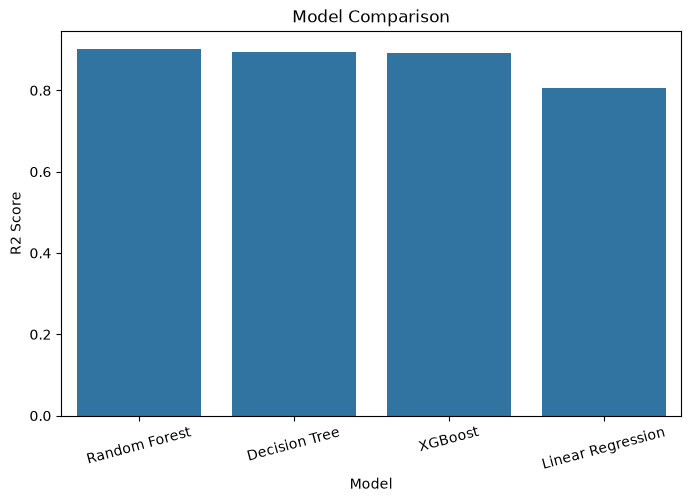

In [197]:
plt.figure(figsize=(8,5))
sns.barplot(data=comparison, x="Model", y="R2 Score")
plt.title("Model Comparison")
plt.xticks(rotation=15)
plt.show()

### *Save Best Model*

In [198]:
models = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

lr_r2 = r2_score(y_test, lr_pred)
dt_r2 = r2_score(y_test, dt_pred)
rf_r2 = r2_score(y_test, rf_pred)
xgb_r2 = r2_score(y_test, xgb_pred)


scores = {
    "Linear Regression": lr_r2,
    "Decision Tree": dt_r2,
    "Random Forest": rf_r2,
    "XGBoost": xgb_r2
}

In [199]:
best_model_name = max(scores, key=scores.get)
best_model = models[best_model_name]

print("="*40)
print("Best Model :", best_model_name)
print("R2 Score   :", round(scores[best_model_name],4))
print("="*40)

Best Model : Random Forest
R2 Score   : 0.9018


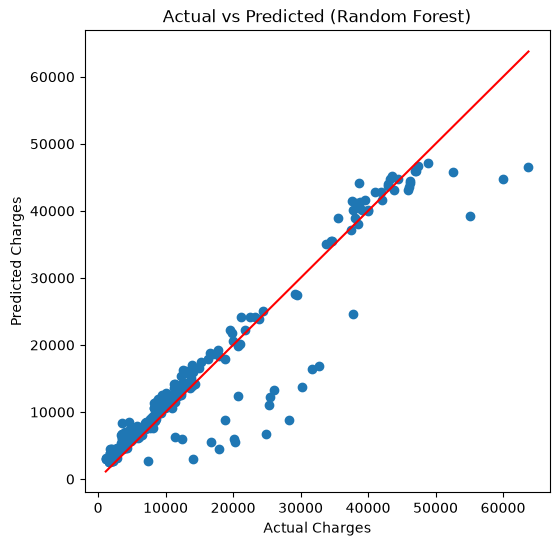

In [200]:
if best_model_name == "Linear Regression":
    best_pred = lr_pred
elif best_model_name == "Decision Tree":
    best_pred = dt_pred
elif best_model_name == "Random Forest":
    best_pred = rf_pred
else:
    best_pred = xgb_pred

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()

In [201]:
import joblib

joblib.dump(best_model, "insurance_model.pkl")
joblib.dump(best_model_name, "model_name.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

print("Best model saved successfully.")

Best model saved successfully.


In [202]:
import joblib
import pandas as pd

# Load model
model = joblib.load("insurance_model.pkl")
model_name = joblib.load("model_name.pkl")
columns = joblib.load("columns.pkl")

# User input
age = int(input("Enter Age: "))
bmi = float(input("Enter BMI: "))
children = int(input("Enter Number of Children: "))

sex = input("Enter Sex (male/female): ").lower()
smoker = input("Smoker? (yes/no): ").lower()
region = input("Region (northeast/northwest/southeast/southwest): ").lower()

# Create input
data = {
    "age": age,
    "bmi": bmi,
    "children": children,
    "sex_male": sex == "male",
    "smoker_yes": smoker == "yes",
    "region_northwest": region == "northwest",
    "region_southeast": region == "southeast",
    "region_southwest": region == "southwest",
}

input_df = pd.DataFrame([data])
input_df = input_df[columns]

# Prediction
prediction = model.predict(input_df)

print("Using Model:", model_name)
print(f"Predicted Insurance Charge: ${prediction[0]:,.2f}")


Using Model: Random Forest
Predicted Insurance Charge: $19,644.19
